# Trade ideas — V-shapes (desk-honest)

Flora & Renò (2020) V-statistic objects for crypto MM / SOR / execution. Labels: **Monitor** / **Exec throttle** / **paper-only**.

**Hard rule:** sized tradable alpha **only** if a Promote (or explicit paper-only Hold) survives falsifiers. Do **not** soft-Promote Holds. Kill objects get **no** trade idea.

**SoT:** [`../DESK_MEMO.md`](../DESK_MEMO.md) §5 · rollup `out/hardening_rollup.json` · ideas `out/trade_ideas.json` · figures under `out/`. Data: HL + Deribit + Kraken warehouse trades + warehouse/collector TOB — **no ClickHouse MCP**.


## 0. Gate status summary

Load hardening rollup → Promote / Hold / Kill board. Trade-idea eligibility follows gates, not narrative.


In [1]:
from pathlib import Path
import json
from IPython.display import Image, display, Markdown

BOOK = Path('/home/dev/srv/ares-microstructure/research/books/v_shapes')
OUT = BOOK / 'out'

rollup = json.loads((OUT / 'hardening_rollup.json').read_text())
ideas = json.loads((OUT / 'trade_ideas.json').read_text())

promotes = rollup.get('promotes') or []
holds = rollup.get('holds') or []
kills = rollup.get('kills') or []

print(f"Program: {len(promotes)} Promote / {len(holds)} Hold / {len(kills)} Kill · days={rollup.get('n_days')} · n_sig5_complete={rollup.get('n_sig5_complete')}")
print('days:', rollup.get('days'))
print()
print('=== PROMOTE ===')
for p in promotes:
    print(f"  {p['id']:28s}  [{p.get('lenses','')}]  {p.get('use','')}")
print('=== HOLD ===')
for h in holds:
    print(f"  {h['id']:28s}  {h.get('why','')[:140]}")
print('=== KILL ===')
for k in kills:
    print(f"  {k['id']:28s}  {k.get('why','')[:140]}")

ts = rollup.get('time_split') or {}
print()
print('time-split early/late sig:', ts.get('early_sig'), '/', ts.get('late_sig'))
print('hn_means (MinV):', {k: round(v, 2) for k, v in (rollup.get('hn_means') or {}).items()})
print('post300:', rollup.get('post300'))
print('concord:', rollup.get('concord'), '| tob n_ok:', (rollup.get('tob') or {}).get('n_ok'))

# idea × gate matrix
print()
print('=== idea × gate matrix ===')
for idea in ideas.get('ideas', []):
    gates = idea.get('gate_status') or {}
    gstr = ', '.join(f"{k.split('.')[-1]}={v}" for k, v in gates.items())
    print(f"{idea['id']:32s}  {idea['label']:14s}  size={idea.get('tradable_size')}")
    print(f"  gates: {gstr}")


Program: 4 Promote / 5 Hold / 2 Kill · days=20 · n_sig5_complete=17
days: ['2026-09-04', '2026-09-05', '2026-09-06', '2026-09-07', '2026-09-08', '2026-09-09', '2026-09-10', '2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-19', '2026-09-20', '2026-09-21', '2026-09-22', '2026-09-25', '2026-09-26', '2026-09-27', '2026-09-30']

=== PROMOTE ===
  risk.v_vs_jump_taxonomy       [risk,info]  V ≠ jump ≠ vol spike ≠ geometric V
  risk.egarch_minv_bands        [risk]  EGARCH simulated bootstrap CIs for MinV
  risk.daily_minv_panel         [risk]  UTC-day MinV vs EGARCH 5% as fragility monitor
  risk.stress_day_minv          [risk,info]  Stress-day MinV narrative reproduced across ≥3 complete days
=== HOLD ===
  risk.xvenue_minv_concord      no concordant significant pair in slice
  info.v_path_continuous        mean_corr_V=0.021 CI=[-0.006,0.048] n=220 (V-only; CI does not clear Promote bar / thin events)
  info.post_trough_ret          post300 mean=0.00020 CI=[-0.00

### Gate counts figure

`out/fig_gate_counts.png` — Promote / Hold / Kill counts from the same rollup.


/home/dev/srv/ares-microstructure/research/books/v_shapes/out/fig_gate_counts.png exists True bytes 16001


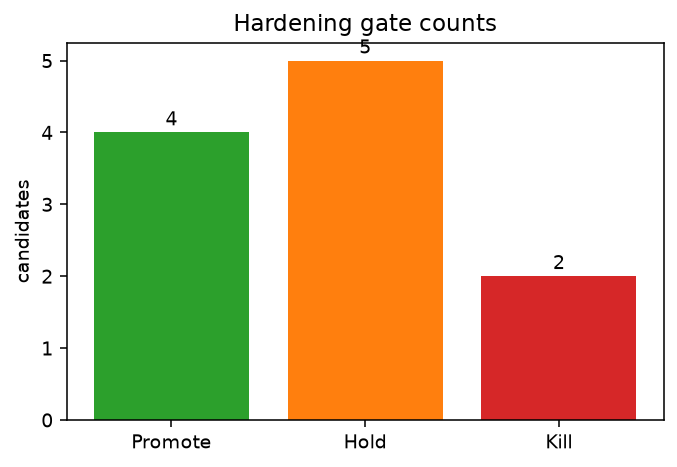

In [2]:
p = OUT / 'fig_gate_counts.png'
print(p, 'exists', p.exists(), 'bytes', p.stat().st_size if p.exists() else 0)
if p.exists():
    display(Image(filename=str(p)))


## 1. `ti.risk_monitor_minv_breach` — **Monitor**

### Thesis
UTC-day MinV vs EGARCH 5% bands is a **fragility / reverting-drift monitor**, not a PnL signal. When home-venue MinV breaches the EGARCH lower band at \(h_n\in\{1,5,30\}\)m, the day is labeled fragile: widen quotes, cut inventory, pause aggressive takes for one \(h_n\) window. Promote stack (`risk.egarch_minv_bands`, `risk.v_vs_jump_taxonomy`, `risk.daily_minv_panel`, `risk.stress_day_minv`) backs the monitor — **not** sized alpha.

### Trigger (exact)
\[
\textbf{fire if}\quad \mathrm{MinV}_{d,v}(h_n) < q_{0.05}^{\mathrm{EGARCH}}(h_n)
\quad\text{for home venue }v,\ h_n\in\{1,5,30\}\text{m, UTC day }d.
\]
Clock: UTC day; significance from EGARCH simulated bootstrap CIs (asymptotic 2.18/3.60 stay **Kill**).

### Action (research knobs — Monitor only)
| Knob | Default research value | Note |
|------|------------------------|------|
| `quote_widen_bps` | +2 … +8 bps on touch | scale with \|MinV\| / \|q05\| |
| `size_mult` | 0.25–0.50 | inventory / child size |
| `aggressive_take` | pause for \(1\times h_n\) | no chase into trough |
| `pov_cap` | optional cut | secondary to widen/size |

**tradable_size:** N/A — Monitor only. Do not size as alpha.


In [3]:
# Evidence: daily MinV panel + stress days + hn fragility
import numpy as np
import pandas as pd

daily_eth = json.loads((OUT / 'daily_minv' / 'daily_minv_eth.json').read_text())
daily_btc = json.loads((OUT / 'daily_minv' / 'daily_minv_btc.json').read_text())
event_eth = json.loads((OUT / 'event_case' / 'event_eth.json').read_text())
event_btc = json.loads((OUT / 'event_case' / 'event_btc.json').read_text())

rows = (daily_eth.get('rows') or []) + (daily_btc.get('rows') or [])
ok5 = [r for r in rows if r.get('ok') and r.get('hn_min') == 5]
sig5 = [r for r in ok5 if r.get('sig_5')]
print(f"daily MinV hn=5m: ok_rows={len(ok5)}  sig_5={len(sig5)}  (ETH days={len(daily_eth.get('days') or [])}, BTC days={len(daily_btc.get('days') or [])})")
print('rollup time-split early/late sig:', (rollup.get('time_split') or {}).get('early_sig'), '/', (rollup.get('time_split') or {}).get('late_sig'))
print('rollup hn_means:', {k: round(v, 2) for k, v in (rollup.get('hn_means') or {}).items()})

# sig table
sig_tbl = pd.DataFrame([
    {
        'symbol': 'ETH' if r in (daily_eth.get('rows') or []) else 'BTC',
        'venue': r['venue'],
        'day': r['day'],
        'min_v': round(r['min_v'], 2),
        'q05': round(r.get('q05', float('nan')), 2),
        'shape': r.get('shape'),
        'tau_star_s': r.get('tau_star_s'),
        'complete': r.get('complete'),
    }
    for r in sig5
]).sort_values(['day', 'venue'])
display(Markdown('**Significant MinV days (hn=5m, EGARCH 5%)**'))
display(sig_tbl)

print()
print('Stress-day cases (Promote risk.stress_day_minv):')
for tag, ev in [('ETH', event_eth), ('BTC', event_btc)]:
    s = ev.get('stress') or {}
    print(f"  {tag}: day={s.get('day')} venue={s.get('venue')} min_v={s.get('min_v'):.2f} shape={s.get('shape')} sig_5={s.get('sig_5')} sig_1={s.get('sig_1')}")

idea1 = next(i for i in ideas['ideas'] if i['id'] == 'ti.risk_monitor_minv_breach')
print()
print('falsifier:', idea1['falsifier'])
print('gate_status:', idea1['gate_status'])
print('→ Monitor OK on Promote stack; early/late both fire (11/6) so not a one-regime fluke — still NOT sized alpha.')


daily MinV hn=5m: ok_rows=99  sig_5=7  (ETH days=20, BTC days=13)
rollup time-split early/late sig: 11 / 6
rollup hn_means: {'1': -18.89, '5': -41.45, '30': -105.83}


**Significant MinV days (hn=5m, EGARCH 5%)**

,symbol,venue,day,min_v,q05,shape,tau_star_s,complete
3,BTC,hyperliquid,2026-09-04,-60.87,-59.85,Lambda,15307.750,True
0,ETH,deribit,2026-09-09,-70.85,-62.64,V,76886.000,True
4,BTC,kraken,2026-09-09,-69.10,-65.99,V,60444.750,True
1,ETH,hyperliquid,2026-09-19,-69.18,-68.82,Lambda,30065.500,True
2,ETH,deribit,2026-09-20,-93.06,-60.33,V,10961.875,True
5,BTC,kraken,2026-09-25,-58.81,-57.15,V,6692.750,True
6,BTC,hyperliquid,2026-09-30,-74.76,-61.55,Lambda,55926.500,True



Stress-day cases (Promote risk.stress_day_minv):
  ETH: day=2026-09-20 venue=deribit min_v=-93.06 shape=V sig_5=True sig_1=True
  BTC: day=2026-09-30 venue=hyperliquid min_v=-74.76 shape=Lambda sig_5=True sig_1=False

falsifier: time-split early/late sig=11/6; hn_means={1: -18.89, 5: -41.45, 30: -105.83}
gate_status: {'risk.egarch_minv_bands': 'Promote', 'risk.v_vs_jump_taxonomy': 'Promote', 'risk.daily_minv_panel': 'Promote'}
→ Monitor OK on Promote stack; early/late both fire (11/6) so not a one-regime fluke — still NOT sized alpha.


### Figures — daily MinV panel + \(h_n\) fragility

Red rings = EGARCH 5% significant. Fragility curve = mean MinV by \(h_n\).


daily_minv/fig_minv_panel.png exists True


`daily_minv/fig_minv_panel.png`

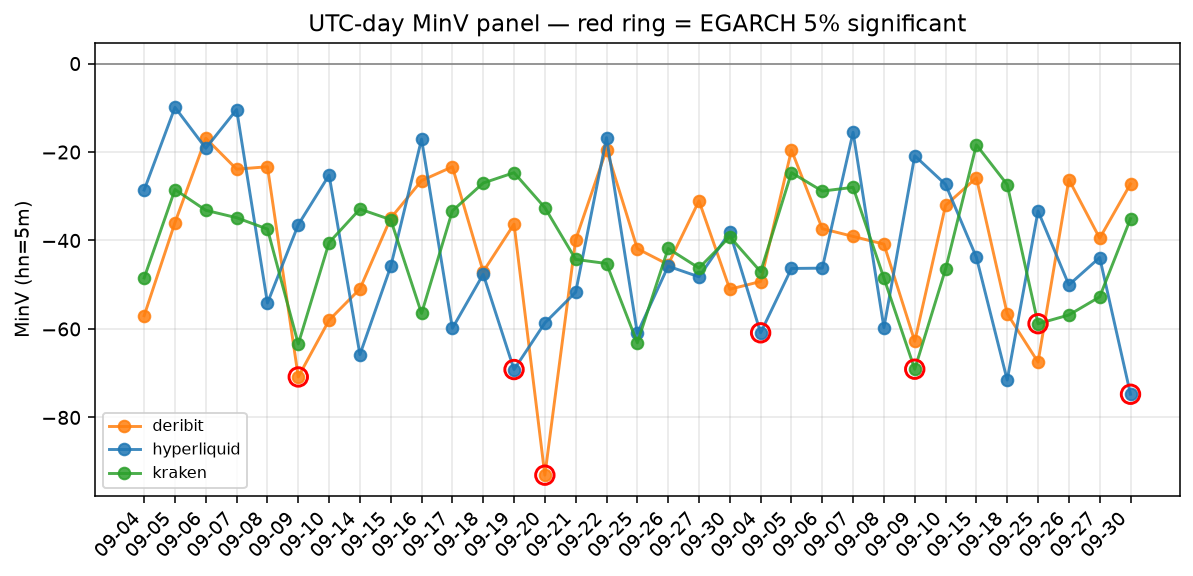

daily_minv/fig_hn_fragility.png exists True


`daily_minv/fig_hn_fragility.png`

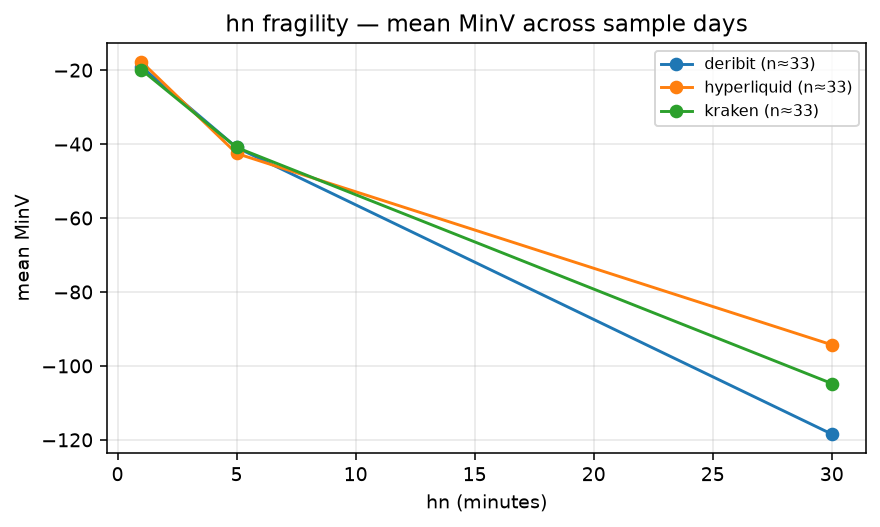

v_statistic/fig_minv_core.png exists True


`v_statistic/fig_minv_core.png`

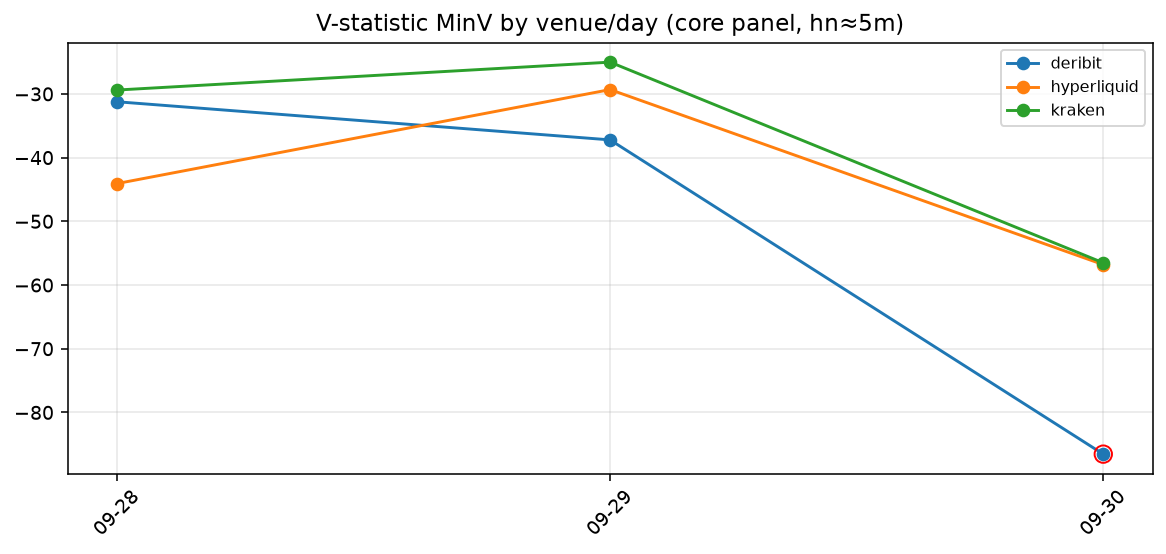

In [4]:
for rel in ['daily_minv/fig_minv_panel.png', 'daily_minv/fig_hn_fragility.png', 'v_statistic/fig_minv_core.png']:
    p = OUT / rel
    print(rel, 'exists', p.exists())
    if p.exists():
        display(Markdown(f'`{rel}`'))
        display(Image(filename=str(p)))


## 2. `ti.exec_throttle_avoid_chase` — **Exec throttle** (paper-only while Hold)

### Thesis
Around a MinV trough, chasing mid through \(\tau^\star\) is an execution leak, not an edge. If live \(V_t\) / MinV path approaches trough (\(T^-\ll 0\) then \(T^+\) rising), **delay POV / cut participation** until mid recovers past \(\tau^\star + h_n/2\). This is a throttle policy — **not** alpha. Gate `info.v_path_continuous` is **Hold** (V→fwdret CI does not clear 0), so params stay **paper-only**.

### Trigger (exact)
\[
\textbf{throttle if}\quad \mathrm{MinV}_{d,v}\ \mathrm{sig@5\%}\ \land\ \text{live path in }[\tau^\star - h_n,\ \tau^\star + h_n/2]
\]
Optional continuity join: \(\mathrm{corr}(V_t, r^{\mathrm{fwd}}_{5\mathrm{s}})\) — currently Hold (CI includes 0).

### Action (paper-only knobs)
| Knob | Paper default | Gate |
|------|---------------|------|
| `pov_pause` | True until mid > mid(\(\tau^\star+h_n/2\)) | paper-only |
| `participation_mult` | 0.0–0.3 during trough window | paper-only |
| `chase_disable` | True | paper-only |

**tradable_size:** Paper-only throttle params — do not Promote to live size until `info.v_path_continuous` clears.


In [5]:
# Evidence: continuous V lead/lag + post paths
cont_eth = json.loads((OUT / 'v_statistic' / 'continuous_v_eth.json').read_text())
cont_btc = json.loads((OUT / 'v_statistic' / 'continuous_v_btc.json').read_text())

def show_cont(tag, c):
    print(f'=== {tag} continuous V ===')
    print('n_ok', c.get('n_ok'), 'n_events', c.get('n_events'), 'promote_hint_v_path', c.get('promote_hint_v_path'))
    print('post300', c.get('post300'))
    agg = c.get('leadlag_agg') or {}
    keys = ['corr_V_fwdret_5s', 'corr_V_fwdret_30s', 'corr_V_fwdret_60s', 'corr_V_fwdret_300s',
            'corr_Tm_fwdret_5s', 'corr_Tp_fwdret_5s']
    rows = []
    for k in keys:
        a = agg.get(k) or {}
        if not a:
            continue
        rows.append({
            'metric': k,
            'mean': round(a.get('mean', float('nan')), 4),
            'lo': round(a.get('lo', float('nan')), 4),
            'hi': round(a.get('hi', float('nan')), 4),
            'n': a.get('n'),
            'excludes_0': a.get('excludes_0'),
        })
    display(pd.DataFrame(rows))
    for r in (c.get('rows') or []):
        if not r.get('ok'):
            continue
        print(f"  event {r['venue']} {r['day']}: min_v={r['min_v']:.2f} shape={r.get('shape')} panel_sig5={r.get('panel_sig5')}")

show_cont('ETH', cont_eth)
show_cont('BTC', cont_btc)

idea2 = next(i for i in ideas['ideas'] if i['id'] == 'ti.exec_throttle_avoid_chase')
print()
print('rollup Hold why (info.v_path_continuous):', next(h['why'] for h in holds if h['id'] == 'info.v_path_continuous'))
print('falsifier:', idea2['falsifier'])
print('→ Exec throttle stays paper-only. mean_corr_V≈0.021 CI straddles 0 — NOT sized alpha / NOT soft-Promote.')


=== ETH continuous V ===
n_ok 3 n_events 3 promote_hint_v_path False
post300 {'mean': 0.0014054923916451874, 'lo': -0.00041768162070335226, 'hi': 0.003228666403993727, 'n': 3, 'excludes_0': False}


,metric,mean,lo,hi,n,excludes_0
0,corr_V_fwdret_5s,0.0214,-0.0721,0.1148,3,False
1,corr_V_fwdret_30s,-0.0826,-0.2685,0.1032,3,False
2,corr_V_fwdret_60s,-0.0493,-0.3537,0.2550,3,False
3,corr_V_fwdret_300s,-0.3186,-0.6306,-0.0065,3,False
4,corr_Tm_fwdret_5s,0.1668,0.0285,0.3051,3,False
5,corr_Tp_fwdret_5s,0.1640,0.0309,0.2971,3,False


  event deribit 2026-09-09: min_v=-70.85 shape=V panel_sig5=True
  event hyperliquid 2026-09-19: min_v=-28.37 shape=V panel_sig5=True
  event deribit 2026-09-20: min_v=-18.43 shape=Lambda panel_sig5=True
=== BTC continuous V ===
n_ok 4 n_events 4 promote_hint_v_path False
post300 {'mean': 0.002540572948988462, 'lo': -0.0003007649032175999, 'hi': 0.005381910801194524, 'n': 4, 'excludes_0': False}


,metric,mean,lo,hi,n,excludes_0
0,corr_V_fwdret_5s,0.0656,0.0185,0.1128,4,False
1,corr_V_fwdret_30s,0.1818,-0.0016,0.3652,4,False
2,corr_V_fwdret_60s,0.1080,-0.0222,0.2381,4,False
3,corr_V_fwdret_300s,0.1163,-0.0653,0.2979,4,False
4,corr_Tm_fwdret_5s,0.0796,-0.1143,0.2735,4,False
5,corr_Tp_fwdret_5s,0.3328,0.2312,0.4344,4,False


  event hyperliquid 2026-09-04: min_v=-45.31 shape=V panel_sig5=True
  event kraken 2026-09-09: min_v=-16.03 shape=Lambda panel_sig5=True
  event kraken 2026-09-25: min_v=-53.37 shape=V panel_sig5=True
  event hyperliquid 2026-09-30: min_v=-29.90 shape=V panel_sig5=True

rollup Hold why (info.v_path_continuous): mean_corr_V=0.021 CI=[-0.006,0.048] n=220 (V-only; CI does not clear Promote bar / thin events)
falsifier: mean_corr_V=0.021 CI=[-0.006,0.048] n=220 (V-only; CI does not clear Promote bar / thin events)
→ Exec throttle stays paper-only. mean_corr_V≈0.021 CI straddles 0 — NOT sized alpha / NOT soft-Promote.


## 3. `ti.mean_reversion_fade` — **Monitor / paper-only** (Hold)

### Thesis
Post-trough mean-reversion fade would be the only candidate that *looks* like tradable alpha. It is **not** sized: `info.post_trough_ret` is **Hold** — post-300s return CI includes 0 on the complete-day sample.

### Trigger (exact) — would-be; currently blocked
\[
\textbf{fade long/short post-}\tau^\star\textbf{ only if}\quad
\mathrm{CI}(\bar r_{300\mathrm{s}})\ \text{excludes }0
\ \text{after time-split + bootstrap}.
\]
**Current status:** blocked. Treat as paper monitor of the CI only.

### Action
| Knob | Value | Status |
|------|-------|--------|
| `fade_size` | — | **not sized** |
| `horizon` | 300s (primary), 60s / 1800s diagnostics | Hold |
| paper log | record post-τ* returns on sig days | OK |

**tradable_size:** Paper-only / not sized — post300 mean≈0.00020 CI≈[-0.00129, 0.00169] n=17.


rollup post300: {'mean': 0.00020113228361390615, 'lo': -0.0012886478134290962, 'hi': 0.0016909123806569085, 'n': 17}
excludes_0? False


**Post-trough returns on sig@5% hn=5m rows**

,symbol,venue,day,min_v,ret_60s,ret_300s,ret_1800s
0,ETH,deribit,2026-09-09,-70.85,0.000385,0.002675,-0.001808
1,ETH,hyperliquid,2026-09-19,-69.18,-0.001808,-0.003808,-0.002110
2,ETH,deribit,2026-09-20,-93.06,0.002277,0.007182,0.007916
3,BTC,hyperliquid,2026-09-04,-60.87,-0.000955,-0.002741,-0.000700
4,BTC,kraken,2026-09-09,-69.10,0.000321,0.002282,0.003255
5,BTC,kraken,2026-09-25,-58.81,0.002199,0.003321,-0.000610
6,BTC,hyperliquid,2026-09-30,-74.76,-0.001508,-0.002400,-0.001223


ret_60s: n=7 mean=0.000130  [-0.001718, 0.002253]
ret_300s: n=7 mean=0.000930  [-0.003488, 0.006023]
ret_1800s: n=7 mean=0.000674  [-0.002019, 0.006518]

falsifier: post300 mean=0.00020 CI=[-0.00129,0.00169] n=17
→ CI includes 0 — failed fade as sized alpha. Keep as Monitor of the CI only.

fig_post_trough True


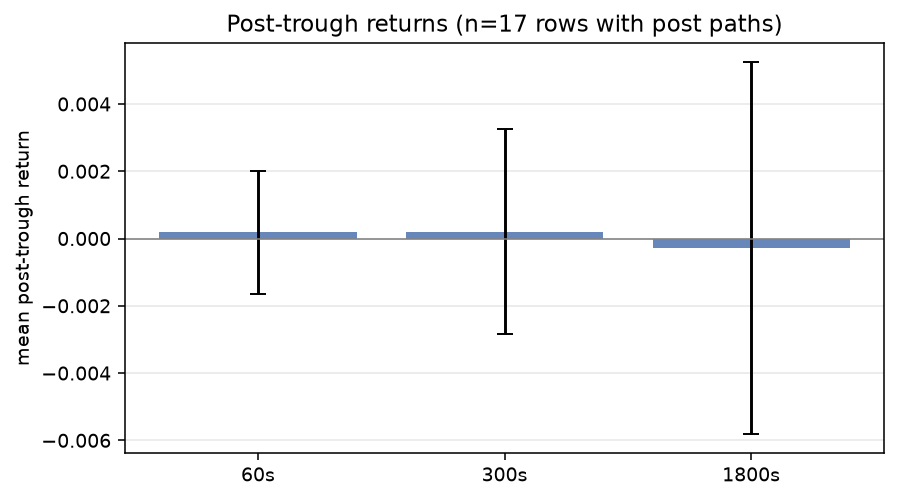

In [6]:
# Evidence: post-trough returns from rollup + daily rows + figure
p300 = rollup.get('post300') or {}
print('rollup post300:', p300)
print('excludes_0?', (p300.get('lo', -1) > 0) or (p300.get('hi', 1) < 0))

# per-row post_trough on sig days
pt_rows = []
for sym, blob in [('ETH', daily_eth), ('BTC', daily_btc)]:
    for r in blob.get('rows') or []:
        if not (r.get('ok') and r.get('sig_5') and r.get('hn_min') == 5 and r.get('post_trough')):
            continue
        pt = r['post_trough']
        pt_rows.append({
            'symbol': sym, 'venue': r['venue'], 'day': r['day'],
            'min_v': round(r['min_v'], 2),
            'ret_60s': pt.get('ret_60s'),
            'ret_300s': pt.get('ret_300s'),
            'ret_1800s': pt.get('ret_1800s'),
        })
pt = pd.DataFrame(pt_rows)
display(Markdown('**Post-trough returns on sig@5% hn=5m rows**'))
display(pt)
if len(pt):
    for col in ['ret_60s', 'ret_300s', 'ret_1800s']:
        vals = pt[col].dropna().astype(float)
        if len(vals):
            print(f'{col}: n={len(vals)} mean={vals.mean():.6f}  [{vals.quantile(0.05):.6f}, {vals.quantile(0.95):.6f}]')

idea3 = next(i for i in ideas['ideas'] if i['id'] == 'ti.mean_reversion_fade')
print()
print('falsifier:', idea3['falsifier'])
print('→ CI includes 0 — failed fade as sized alpha. Keep as Monitor of the CI only.')

p = OUT / 'daily_minv' / 'fig_post_trough.png'
print()
print('fig_post_trough', p.exists())
if p.exists():
    display(Image(filename=str(p)))


## 4. `ti.xvenue_sor_caution` — **Exec throttle** (Hold)

### Thesis
If HL↔Deribit↔Kraken MinV troughs are **concordant** (pairwise \(|\Delta\tau^\star|\le h_n\) among significant venues), cut child size on the thin venue during the V window. Concordance is a fragmentation / timing caution — not a cross lead-lag alpha.

### Trigger (exact) — blocked
\[
\textbf{caution if}\quad \exists\ \mathrm{sig}\ \mathrm{pair}\ (v_i,v_j):\ |\tau^\star_i-\tau^\star_j|\le h_n.
\]
**Current:** `risk.xvenue_minv_concord` = **Hold** — `concordant_pair_in_slice=False`.

### Action
| Knob | Value | Status |
|------|-------|--------|
| `thin_venue_size_mult` | 0.25 (would-be) | **not sized** until concordant pairs exist |
| `prefer_home_venue` | True | Hold |

**tradable_size:** Not sized until concordant pairs exist.


**Cross-venue MinV concordance by day**

,symbol,day,n_complete,sig_venues,n_pairs,n_concord_5m
0,ETH,2026-09-08,3,—,0,0
1,ETH,2026-09-15,3,—,0,0
2,ETH,2026-09-20,3,deribit,0,0
3,ETH,2026-09-25,3,—,0,0
4,ETH,2026-09-27,3,—,0,0
5,ETH,2026-09-29,0,—,0,0
6,ETH,2026-09-30,3,—,0,0
7,BTC,2026-09-08,3,—,0,0
8,BTC,2026-09-15,3,—,0,0
9,BTC,2026-09-20,3,—,0,0


total concordant pairs ETH+BTC: 0  (rollup.concord=False)
Hold why: no concordant significant pair in slice
→ No SOR thin-venue cut sized. Monitor completeness only.


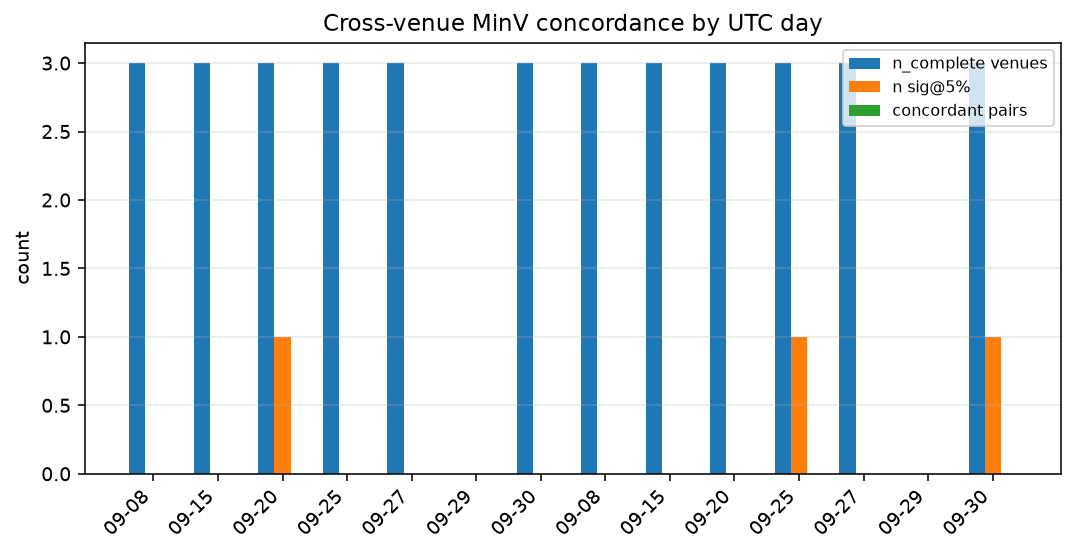

In [7]:
# Evidence: xvenue concordance
x_eth = json.loads((OUT / 'xvenue_concord' / 'xvenue_eth.json').read_text())
x_btc = json.loads((OUT / 'xvenue_concord' / 'xvenue_btc.json').read_text())

def xvenue_table(tag, blob):
    rows = []
    n_conc = 0
    for r in blob.get('rows') or []:
        pairs = r.get('pairs') or []
        n_c = sum(1 for p in pairs if p.get('concord_5m'))
        n_conc += n_c
        rows.append({
            'symbol': tag,
            'day': r.get('day'),
            'n_complete': r.get('n_complete'),
            'sig_venues': ','.join(r.get('sig_venues') or []) or '—',
            'n_pairs': len(pairs),
            'n_concord_5m': n_c,
        })
    return pd.DataFrame(rows), n_conc

te, ne = xvenue_table('ETH', x_eth)
tb, nb = xvenue_table('BTC', x_btc)
display(Markdown('**Cross-venue MinV concordance by day**'))
display(pd.concat([te, tb], ignore_index=True))
print(f"total concordant pairs ETH+BTC: {ne + nb}  (rollup.concord={rollup.get('concord')})")
print('Hold why:', next(h['why'] for h in holds if h['id'] == 'risk.xvenue_minv_concord'))
print('→ No SOR thin-venue cut sized. Monitor completeness only.')

p = OUT / 'xvenue_concord' / 'fig_concord.png'
if p.exists():
    display(Image(filename=str(p)))


## 5. `ti.liq_spread_widen` — **Monitor** (Hold / secondary)

### Thesis
If TOB spread widens into the MinV trough, reinforce the risk-monitor quote widen. This is a **secondary** liquidity flag — never a standalone Promote without honest TOB.

### Trigger (exact) — weak / Hold
\[
\Delta\mathrm{spread} = \mathrm{spread}^{\mathrm{post}}_{\mathrm{bps}} - \mathrm{spread}^{\mathrm{pre}}_{\mathrm{bps}}
\quad\text{around }\tau^\star;\quad
\textbf{reinforce widen if}\ \Delta\mathrm{spread}>0\ \text{with CI excluding 0}.
\]
**Current:** Hold — usable TOB days thin; \(\Delta\)spread CI includes 0; Kraken warehouse L2 empty; collector TOB only 2026-09-29/30; Deribit L2 multi-day when present.

### Action
| Knob | Value | Status |
|------|-------|--------|
| `reinforce_widen_bps` | +1 … +4 (would-be) | Hold — no fake TOB |
| TOB source allowlist | Deribit warehouse L2; collector when present | hard ceiling |

**tradable_size:** N/A — Monitor; no fake TOB / no trade_synth Promote.


**TOB join around MinV (honest coverage)**

,symbol,venue,day,min_v,sig_5,tob_ok,spread_pre,spread_post,dspread,tob_source
0,ETH,hyperliquid,2026-09-08,-54.138239,False,False,NaN,NaN,NaN,tob_unavailable
1,ETH,deribit,2026-09-08,-23.328852,False,True,254.987008,140.974386,-114.012622,warehouse:l2_snapshot_level/warehouse:l2_tob/s...
2,ETH,kraken,2026-09-08,-37.419239,False,False,NaN,NaN,NaN,tob_unavailable
3,ETH,hyperliquid,2026-09-15,-45.870159,False,True,0.402585,0.403299,0.000714,warehouse:l2_snapshot_level/warehouse:l2_tob/s...
4,ETH,deribit,2026-09-15,-34.945219,False,False,NaN,NaN,NaN,warehouse:l2_snapshot_level/warehouse:l2_tob/s...
5,ETH,kraken,2026-09-15,-35.295803,False,False,NaN,NaN,NaN,tob_unavailable
6,ETH,hyperliquid,2026-09-20,-58.639948,False,False,NaN,NaN,NaN,tob_unavailable
7,ETH,deribit,2026-09-20,-93.056482,True,False,NaN,NaN,NaN,warehouse:l2_snapshot_level/warehouse:l2_tob/s...
8,ETH,kraken,2026-09-20,-32.568571,False,False,NaN,NaN,NaN,tob_unavailable
9,ETH,hyperliquid,2026-09-25,-60.980533,False,False,NaN,NaN,NaN,warehouse:l2_snapshot_level/warehouse:l2_tob/s...


usable TOB rows: 14 / 42
Δspread(post-pre) n=14 mean=36.9079  p05=-177.2641 p95=334.0550
rollup tob: {'n_ok': 14, 'days': ['2026-09-08', '2026-09-15', '2026-09-25', '2026-09-27', '2026-09-29', '2026-09-30'], 'sources': ['collector', 'warehouse:l2_snapshot_level/warehouse:l2_tob/s3_cache']}
Hold why: TOB usable rows=14 days=['2026-09-08', '2026-09-15', '2026-09-25', '2026-09-27', '2026-09-29', '2026-09-30'] sources=['collector', 'warehouse:l2_snapshot_level/warehouse:l2_tob/s3_cache']; Δspread(post-pre) mean=-0.0749 CI=[-0.2234,0.0737] n_sane=8 (Kraken warehouse L2 empty; col
→ Secondary flag only; CI does not Promote. No fake TOB.


`liq_around_v/fig_spread_around.png`

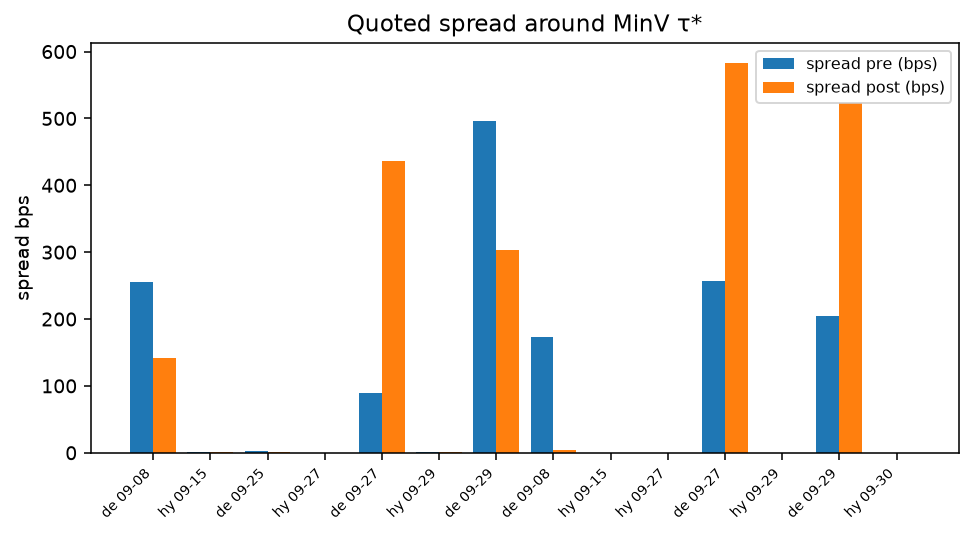

In [8]:
# Evidence: liq around V / TOB
liq_eth = json.loads((OUT / 'liq_around_v' / 'liq_eth.json').read_text())
liq_btc = json.loads((OUT / 'liq_around_v' / 'liq_btc.json').read_text())

def liq_frame(tag, blob):
    rows = []
    for r in blob.get('rows') or []:
        liq = r.get('liq') or {}
        rows.append({
            'symbol': tag,
            'venue': r.get('venue'),
            'day': r.get('day'),
            'min_v': (r.get('minv') or {}).get('min_v'),
            'sig_5': (r.get('minv') or {}).get('sig_5'),
            'tob_ok': 'spread_bps_mean' in liq,
            'spread_pre': liq.get('spread_bps_pre'),
            'spread_post': liq.get('spread_bps_post'),
            'dspread': (liq.get('spread_bps_post') - liq.get('spread_bps_pre'))
                       if ('spread_bps_post' in liq and 'spread_bps_pre' in liq) else None,
            'tob_source': liq.get('tob_source') or liq.get('note') or r.get('tob_error', '')[:40],
        })
    return pd.DataFrame(rows)

lf = pd.concat([liq_frame('ETH', liq_eth), liq_frame('BTC', liq_btc)], ignore_index=True)
display(Markdown('**TOB join around MinV (honest coverage)**'))
display(lf)

usable = lf[lf['tob_ok'] == True]
print(f"usable TOB rows: {len(usable)} / {len(lf)}")
if len(usable):
    ds = usable['dspread'].dropna().astype(float)
    print(f"Δspread(post-pre) n={len(ds)} mean={ds.mean():.4f}  p05={ds.quantile(0.05):.4f} p95={ds.quantile(0.95):.4f}")
print('rollup tob:', rollup.get('tob'))
print('Hold why:', next(h['why'] for h in holds if h['id'] == 'liq.spread_around_minv')[:280])
print('→ Secondary flag only; CI does not Promote. No fake TOB.')

for rel in ['liq_around_v/fig_spread_around.png', 'liq_around_v/fig_tob_coverage.png']:
    p = OUT / rel
    if p.exists():
        display(Markdown(f'`{rel}`'))
        display(Image(filename=str(p)))


## 6. What we will NOT trade

Explicit kill / failed-fade list. No alpha cosplay.


=== KILL objects — no trade ideas ===
  risk.asymptotic_218_360: No trade idea — Kill object. Do not alpha-cosplay.
  risk.gm_mu_sigma_tradable: No trade idea — Kill object. Do not alpha-cosplay.
  info.v_feature_leakage_V_Tp: No trade idea — Kill object (right-kernel V/T+ leakage). Do not alpha-cosplay.

asymptotic bands artifact: {'band_95': 2.18, 'band_99': 3.6, 'decision': 'Kill', 'reason': 'paper §3.1: too small for realistic DGP + multiple testing; use EGARCH bootstrap'}

=== Failed / blocked fades (Hold — not sized) ===
  ti.mean_reversion_fade: post300 CI includes 0 → NOT tradable mean-reversion
  ti.exec_throttle_avoid_chase: V-path CI Hold → paper throttle only, not alpha
  ti.xvenue_sor_caution: no concordant sig pair → no thin-venue size cut
  ti.liq_spread_widen: Δspread CI / TOB ceiling → secondary monitor only
  id.auction_loss: no crypto sovereign auction analogue → identification Hold, no trade

=== Vanity / wrong object ===
  risk.gm_mu_sigma_tradable: Grossman–Miller

`bootstrap_sim/fig_size_power.png` — size/power vs kill asymptotic framing

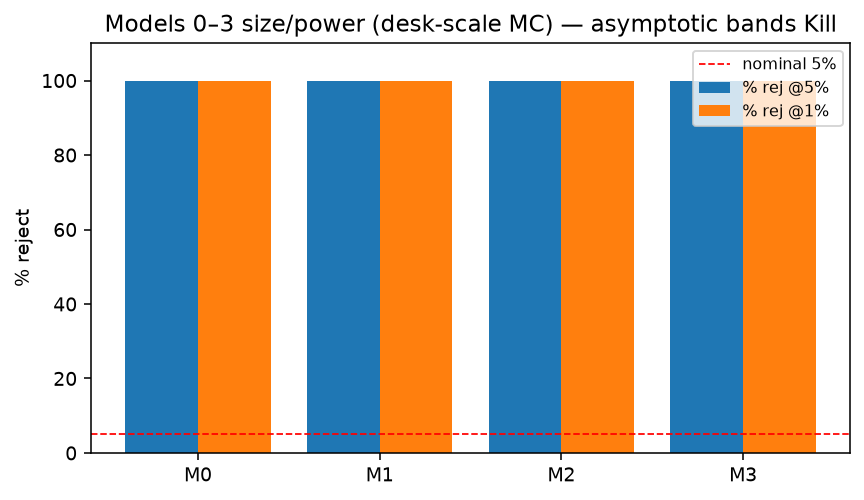

In [9]:
kill_bands = json.loads((OUT / 'bootstrap_sim' / 'kill_asymptotic_bands.json').read_text())
print('=== KILL objects — no trade ideas ===')
for k in ideas.get('kill_no_alpha') or []:
    print(f"  {k['id']}: {k['note']}")
print()
print('asymptotic bands artifact:', kill_bands)
print()
print('=== Failed / blocked fades (Hold — not sized) ===')
print('  ti.mean_reversion_fade: post300 CI includes 0 → NOT tradable mean-reversion')
print('  ti.exec_throttle_avoid_chase: V-path CI Hold → paper throttle only, not alpha')
print('  ti.xvenue_sor_caution: no concordant sig pair → no thin-venue size cut')
print('  ti.liq_spread_widen: Δspread CI / TOB ceiling → secondary monitor only')
print('  id.auction_loss: no crypto sovereign auction analogue → identification Hold, no trade')
print()
print('=== Vanity / wrong object ===')
print('  risk.gm_mu_sigma_tradable: Grossman–Miller μ/σ = monitor vanity as tradable → Kill')
print('  risk.asymptotic_218_360: paper §3.1 bands too small under realistic DGP → Kill; use EGARCH bootstrap')

p = OUT / 'bootstrap_sim' / 'fig_size_power.png'
if p.exists():
    display(Markdown('`bootstrap_sim/fig_size_power.png` — size/power vs kill asymptotic framing'))
    display(Image(filename=str(p)))


## 7. Next experiments checklist (tied to remaining Holds)

Do **not** soft-Promote. Each item must clear its falsifier before any label upgrade.


In [10]:
checklist = [
    {
        'hold': 'info.post_trough_ret',
        'idea': 'ti.mean_reversion_fade',
        'experiment': 'Widen complete-day sig sample; time-split + block bootstrap on ret_300s; require CI excludes 0 on early AND late',
        'upgrade_if': 'post300 CI excludes 0 with n≥30 complete sig days',
        'else': 'stay paper-only Monitor — no sized fade',
    },
    {
        'hold': 'info.v_path_continuous',
        'idea': 'ti.exec_throttle_avoid_chase',
        'experiment': 'More continuous-V events (ETH+BTC×venues); report corr(V, fwdret) CIs at 5/30/60s; joint with T±',
        'upgrade_if': 'corr_V_fwdret CI excludes 0 (or T± path clears) with n_ok≫3',
        'else': 'paper POV pause only — never market as alpha',
    },
    {
        'hold': 'risk.xvenue_minv_concord',
        'idea': 'ti.xvenue_sor_caution',
        'experiment': 'Expand multi-venue complete days; pairwise |Δτ*|≤hn among sig; Kraken tape completeness probe',
        'upgrade_if': '≥1 concordant significant pair replicated across weeks',
        'else': 'no thin-venue size mult',
    },
    {
        'hold': 'liq.spread_around_minv',
        'idea': 'ti.liq_spread_widen',
        'experiment': 'Deribit warehouse L2 multi-day + collector TOB; refuse Kraken trade_synth; Δspread CI',
        'upgrade_if': 'Δspread CI excludes 0 on sane TOB rows with honest source labels',
        'else': 'secondary flag only / no fake TOB',
    },
    {
        'hold': 'id.auction_loss',
        'idea': '(none)',
        'experiment': 'No crypto sovereign auction analogue — keep identification Hold; do not invent a proxy trade',
        'upgrade_if': 'N/A',
        'else': 'no trade idea forever unless true auction microstructure appears',
    },
]

checklist += [
    {
        'hold': 'info.v_feature_ridge_tick',
        'idea': 'ti.v_feature_ridge_monitor',
        'experiment': 'Primary trade-clock Ridge failed OOS; keep as IC monitor; do not size',
        'upgrade_if': 'R2_te>0 and IC CI excludes 0 with early/late sign-stable on y_tick_20',
        'else': 'stay Monitor — calendar Promote is the usable info path',
    },
    {
        'hold': 'info.v_path_continuous',
        'idea': 'ti.v_feature_throttle_join',
        'experiment': 'Join calendar Ridge score into paper POV throttle; still need v_path CI clear for live',
        'upgrade_if': 'v_path continuous Promote AND calendar Monitor still holds',
        'else': 'paper throttle join only',
    },
]

display(pd.DataFrame(checklist))
print()
print('Promote stack already live as MONITOR only:')
for p in promotes:
    print(f"  ✓ {p['id']} — use={p.get('use')}")
print()
print('Done. No soft-Promotes. No sized tradable alpha cosplay.')


,hold,idea,experiment,upgrade_if,else
0,info.post_trough_ret,ti.mean_reversion_fade,Widen complete-day sig sample; time-split + bl...,post300 CI excludes 0 with n≥30 complete sig days,stay paper-only Monitor — no sized fade
1,info.v_path_continuous,ti.exec_throttle_avoid_chase,More continuous-V events (ETH+BTC×venues); rep...,corr_V_fwdret CI excludes 0 (or T± path clears...,paper POV pause only — never market as alpha
2,risk.xvenue_minv_concord,ti.xvenue_sor_caution,Expand multi-venue complete days; pairwise |Δτ...,≥1 concordant significant pair replicated acro...,no thin-venue size mult
3,liq.spread_around_minv,ti.liq_spread_widen,Deribit warehouse L2 multi-day + collector TOB...,Δspread CI excludes 0 on sane TOB rows with ho...,secondary flag only / no fake TOB
4,id.auction_loss,(none),No crypto sovereign auction analogue — keep id...,N/A,no trade idea forever unless true auction micr...
5,info.v_feature_ridge_tick,ti.v_feature_ridge_monitor,Primary trade-clock Ridge failed OOS; keep as ...,R2_te>0 and IC CI excludes 0 with early/late s...,stay Monitor — calendar Promote is the usable ...
6,info.v_path_continuous,ti.v_feature_throttle_join,Join calendar Ridge score into paper POV throt...,v_path continuous Promote AND calendar Monitor...,paper throttle join only



Promote stack already live as MONITOR only:
  ✓ risk.v_vs_jump_taxonomy — use=V ≠ jump ≠ vol spike ≠ geometric V
  ✓ risk.egarch_minv_bands — use=EGARCH simulated bootstrap CIs for MinV
  ✓ risk.daily_minv_panel — use=UTC-day MinV vs EGARCH 5% as fragility monitor
  ✓ risk.stress_day_minv — use=Stress-day MinV narrative reproduced across ≥3 complete days

Done. No soft-Promotes. No sized tradable alpha cosplay.


## 8. Feature-reg slice — new ideas (evidence-backed)

Full memo board: [`../applications/feature_reg/feature_reg.ipynb`](../applications/feature_reg/feature_reg.ipynb) · SoT [`../applications/feature_reg/`](../applications/feature_reg/) · artifacts `out/feature_reg/`.

**Primary clock chosen:** trade-time `y_tick_20` (next-20 trades). It **Holds** — negative OOS \(R^2\), IC CI includes 0. **Calendar** 30s/60s/300s **Promotes as Monitor only** (IC stable, \(R^2\) small — not sized alpha). Leakage \(V/T^+\) **Kill**. Do **not** soft-Promote the tick Hold.


In [ ]:
# Feature-reg evidence + new ideas
fr = OUT / 'feature_reg'
summary = json.loads((fr / 'summary.json').read_text())
gates = json.loads((fr / 'gates.json').read_text())

print('memo notebook → applications/feature_reg/feature_reg.ipynb')
print('primary', summary['primary_target'], summary['primary_clock'], 'n_rows', summary['n_rows'])
print()
print('=== feature-reg candidates ===')
for c in gates['candidates']:
    print(f"  {c['decision']:7s}  {c['id']}")
    print(f"           {c['evidence'][:170]}")

print()
print('=== OOS metrics by clock ===')
rows = []
for k, blk in (summary.get('results') or {}).items():
    rg = blk.get('ridge') or {}
    rows.append({
        'target': k,
        'R2_te': round(rg.get('r2_test', float('nan')), 4) if rg.get('r2_test') is not None else None,
        'IC': round(rg.get('ic_test', float('nan')), 4) if rg.get('ic_test') is not None else None,
        'promote_ok': blk.get('promote_ok'),
    })
display(pd.DataFrame(rows))

print()
print('=== new ideas from feature_reg (in trade_ideas.json) ===')
new_ids = {i['id'] for i in (gates.get('trade_ideas_new') or [])}
for idea in ideas.get('ideas', []):
    if idea['id'] in new_ids:
        print(f"{idea['id']:32s}  {idea['label']:14s}  size={idea.get('tradable_size')}")
        print(f"  gates: {idea.get('gate_status')}")

for rel in [
    'feature_reg/figs/ic_by_horizon.png',
    'feature_reg/figs/train_test_split.png',
    'feature_reg/figs/ridge_coefs_primary.png',
    'feature_reg/figs/ridge_coefs_calendar.png',
    'feature_reg/figs/oos_scatter_primary.png',
    'feature_reg/figs/ridge_path.png',
]:
    p = OUT / rel
    if p.exists():
        display(Markdown(f'`{rel}`'))
        display(Image(filename=str(p)))

print()
print('→ ti.v_feature_cal_monitor = Monitor on calendar Promote (NOT sized).')
print('→ ti.v_feature_ridge_monitor = tick primary Hold — IC watch only.')
print('→ ti.v_feature_throttle_join = paper Exec throttle join; v_path still Hold.')
print('No soft-Promote. No sized alpha from feature-reg.')


## 9. Paper exec-throttle harness (pointer)

Full memo: [`../applications/paper_throttle/paper_throttle.ipynb`](../applications/paper_throttle/paper_throttle.ipynb) · SoT [`../applications/paper_throttle/`](../applications/paper_throttle/) · artifacts `out/paper_throttle/`.

Turns Promote MinV/EGARCH monitors into simulated desk throttle vs always-on. **Result:** `exec.minv_breach_throttle` **Kill** (OOS adverse markout CI>0); calendar join **Hold**; alpha **Hold**. Do not soft-Promote. Feature-reg memos above unchanged.


In [ ]:
pt = OUT / 'paper_throttle'
ps = json.loads((pt / 'summary.json').read_text())
pg = json.loads((pt / 'gates.json').read_text())
print('memo → applications/paper_throttle/paper_throttle.ipynb')
print('OOS breach n=', (ps.get('agg_oos_breach') or {}).get('n'))
print('Δmax_dd', (ps.get('agg_oos_breach') or {}).get('d_max_dd_throttle'))
print('Δadverse_mo30', (ps.get('agg_oos_breach') or {}).get('d_adverse_mo_throttle'))
print('Δpnl', (ps.get('agg_oos') or {}).get('d_pnl_throttle'))
print('=== gates ===')
for c in pg.get('candidates') or []:
    print(c['decision'], c['id'], '—', str(c.get('evidence',''))[:140])
for fig in ['breach_timeline.png','oos_risk_deltas.png','cumulative_risk.png','throttle_state_path.png','pnl_vs_risk.png']:
    fp = pt / 'figs' / fig
    print(fig, 'OK' if fp.exists() else 'MISSING')
    if fp.exists():
        display(Image(filename=str(fp)))


## Mapping back to desk jobs

| Desk job | Idea | Label now | Gate dependency |
|----------|------|-----------|-----------------|
| Risk monitor | `ti.risk_monitor_minv_breach` | **Monitor** | EGARCH / daily / taxonomy / stress **Promote** |
| Exec throttle | `ti.exec_throttle_avoid_chase` | paper Exec throttle | `info.v_path_continuous` **Hold** |
| Mean-reversion | `ti.mean_reversion_fade` | paper Monitor | `info.post_trough_ret` **Hold** |
| SOR / x-venue | `ti.xvenue_sor_caution` | Hold | `risk.xvenue_minv_concord` **Hold** |
| Liq secondary | `ti.liq_spread_widen` | Hold Monitor | `liq.spread_around_minv` **Hold** |

| Feature-reg calendar | `ti.v_feature_cal_monitor` | **Monitor** | `info.v_feature_ridge_calendar` **Promote** |
| Feature-reg tick IC | `ti.v_feature_ridge_monitor` | Monitor (Hold) | `info.v_feature_ridge_tick` **Hold** |
| Feature-reg throttle join | `ti.v_feature_throttle_join` | paper Exec throttle | calendar Promote + v_path **Hold** |

See [`../DESK_MEMO.md`](../DESK_MEMO.md) §2 signal board and §5 trade ideas.

Feature-reg memo: [`../applications/feature_reg/feature_reg.ipynb`](../applications/feature_reg/feature_reg.ipynb).
